#### Instructions
###### Follow the instructions given in comments prefixed with ## and write your code below that.
###### Also fill the partial code in given blanks. 
###### Don't make any changes to the rest part of the codes

### Answer the questions given at the end of this notebook within your report.

### You would need to submit your GitHub repository link. Refer to the PDF document for the instructions and details.





C:\Users\shikh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


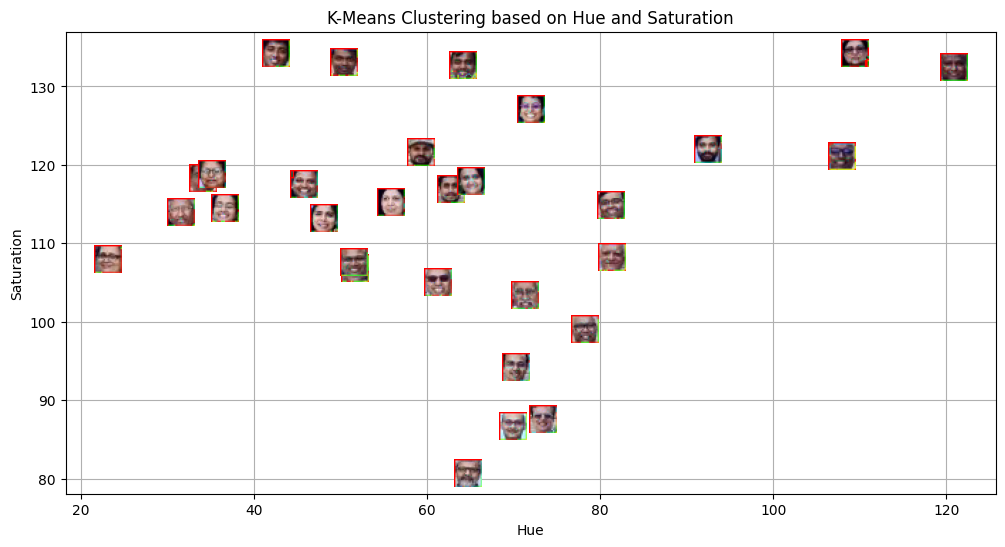

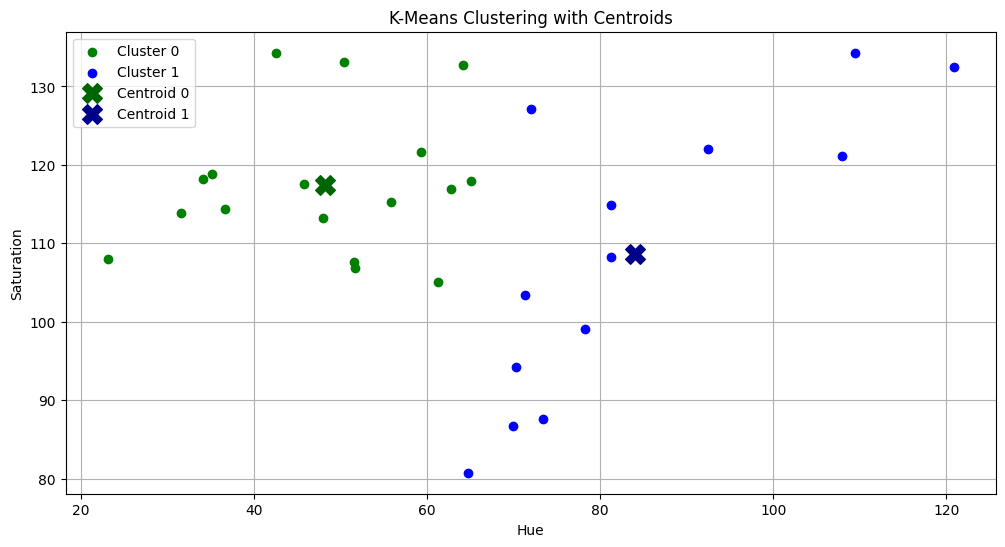

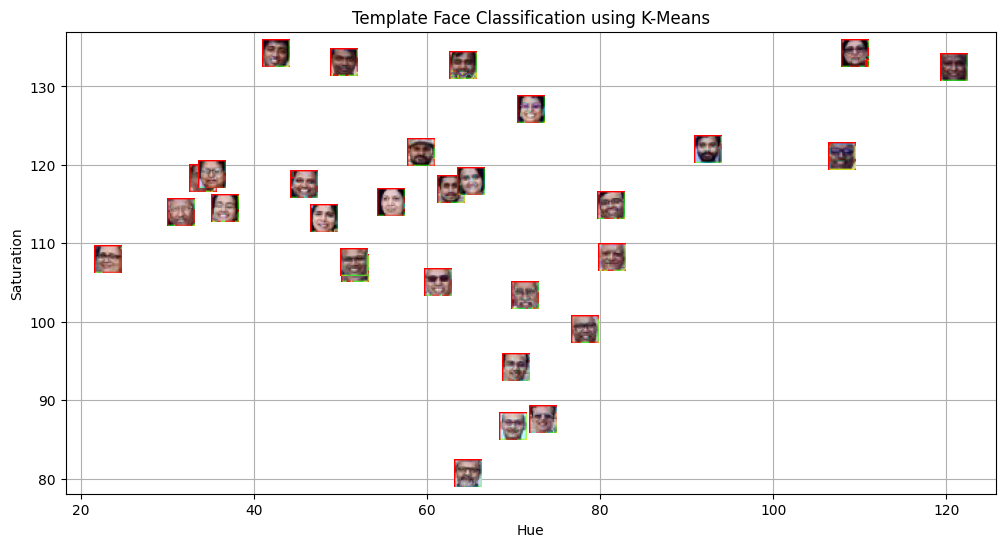

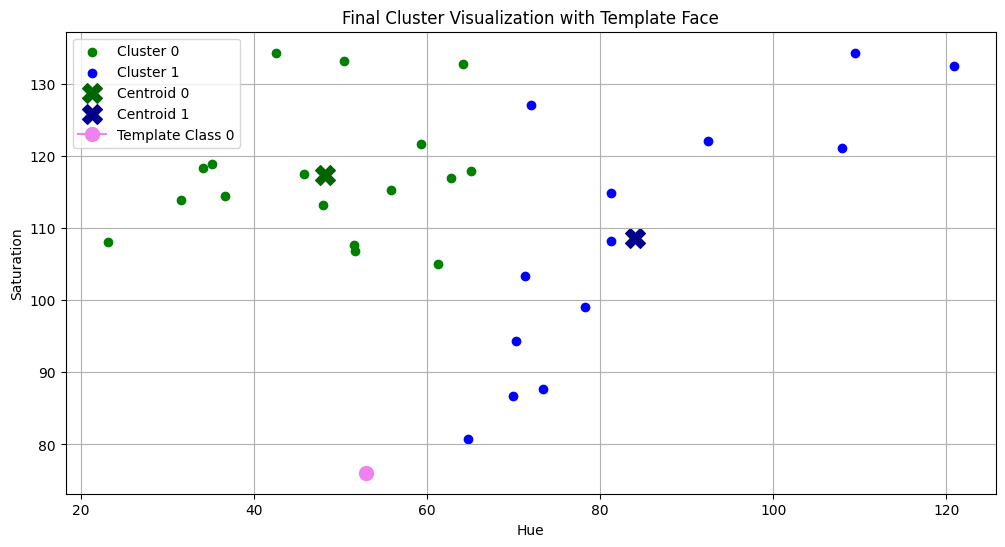

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from sklearn.cluster import KMeans
from scipy.spatial import distance
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

## Reading the image plaksha_Faculty.jpg
img = cv2.imread("Plaksha_Faculty.jpg")

## Convert the image to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Loading the required haar-cascade xml classifier file
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 
                                     "haarcascade_frontalface_default.xml")

# Applying the face detection method on the grayscale image.
## Change the parameters for better detection of faces in your case.
faces_rect = face_cascade.detectMultiScale(gray, 1.05, 4, 
                                           minSize=(25,25), 
                                           maxSize=(50,50))

# Define the text and font parameters
text = "Face"                     ## The text you want to write
font = cv2.FONT_HERSHEY_SIMPLEX   ## Font type
font_scale = 0.5                  ## Font scale factor
font_color = (0, 0, 255)          ## Text color in BGR format (red)
font_thickness = 1                ## Thickness of the text

# Iterating through rectangles of detected faces
for (x, y, w, h) in faces_rect:
    
    cv2.rectangle(img, (x, y), (x+w, y+h), (0, 0, 255), 2)
    
    # Add text above rectangle
    cv2.putText(img, text, (x, y-5), font, 
                font_scale, font_color, font_thickness)

## Display the image and window title should be "Total number of face detected are #"
window_title = "Total number of face detected are " + str(len(faces_rect))

cv2.imshow(window_title, img)
cv2.waitKey(0)
cv2.destroyAllWindows()

from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Extract face region features (Hue and Saturation)
img_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)  ## call the img and convert it from BGR to HSV and store in img_hsv

hue_saturation = []
face_images = []  # To store detected face images

for (x, y, w, h) in faces_rect:
    face = img_hsv[y:y + h, x:x + w]
    hue = np.mean(face[:, :, 0])
    saturation = np.mean(face[:, :, 1])
    hue_saturation.append((hue, saturation))
    face_images.append(face)

hue_saturation = np.array(hue_saturation)

## Perform k-Means clustering on hue_saturation and store in kmeans
kmeans = KMeans(n_clusters=2, random_state=42).fit(hue_saturation)

#centroids = kmeans.cluster_centers_
#labels = kmeans.labels_

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the clustered faces with custom markers
for i, (x,y,w,h ) in enumerate(faces_rect):
    im = OffsetImage(cv2.cvtColor(cv2.resize(face_images[i], (20, 20)), cv2.COLOR_HSV2RGB))
    ab = AnnotationBbox(im, (hue_saturation[i, 0], hue_saturation[i, 1]), frameon=False, pad=0)
    ax.add_artist(ab)
    plt.plot(hue_saturation[i, 0], hue_saturation[i, 1])
    

## Put x label
plt.xlabel("Hue")

## Put y label
plt.ylabel("Saturation")

## Put title
plt.title("K-Means Clustering based on Hue and Saturation")

## Put grid
plt.grid(True)

## show the plot
plt.show()

# Create an empty list to store legend labels
legend_labels = []

# Create lists to store points for each cluster
cluster_0_points = []
cluster_1_points = []

# Your code for scatter plot goes here
fig, ax = plt.subplots(figsize=(12, 6))

for i, (x, y, w, h) in enumerate(faces_rect):
    if kmeans.labels_[i] == 0:
        cluster_0_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))
    else:
        cluster_1_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))


cluster_0_points = np.array(cluster_0_points)

# Plot points for cluster 0 in green
if len(cluster_0_points) > 0:
    plt.scatter(cluster_0_points[:, 0],
                cluster_0_points[:, 1],
                color='green',
                label='Cluster 0')


cluster_1_points = np.array(cluster_1_points)

# Plot points for cluster 1 in blue
if len(cluster_1_points) > 0:
    plt.scatter(cluster_1_points[:, 0],
                cluster_1_points[:, 1],
                color='blue',
                label='Cluster 1')


# Calculate and plot centroids
centroid_0 = kmeans.cluster_centers_[0]
centroid_1 = kmeans.cluster_centers_[1]

# Plot both the centroid for cluster 0 and cluster 1
plt.scatter(centroid_0[0], centroid_0[1],
            marker='X', s=200, color='darkgreen',
            label='Centroid 0')

plt.scatter(centroid_1[0], centroid_1[1],
            marker='X', s=200, color='darkblue',
            label='Centroid 1')


## Put x label
plt.xlabel("Hue")

## Put y label
plt.ylabel("Saturation")

## Put title
plt.title("K-Means Clustering with Centroids")

## Add a legend
plt.legend()

## Add grid
plt.grid(True)

## Show the plot
plt.show()

## Read the class of the template image 'Dr_Shashi_Tharoor.jpg' using cv2 and store it in template_img
template_img = cv2.imread("Dr_Shashi_Tharoor.jpg")

# Detect face in the template image after converting it to gray and store it in template_faces
template_gray = cv2.cvtColor(template_img, cv2.COLOR_BGR2GRAY)
template_faces = face_cascade.detectMultiScale(template_gray, 
                                               scaleFactor=1.3, 
                                               minNeighbors=5)

# Draw rectangles around the detected faces
for (x, y, w, h) in template_faces:
    cv2.rectangle(template_img, (x, y), (x + w, y + h), (0, 255, 0), 3)

cv2.imshow("Detected Face in Template Image", template_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

# Convert the template image to HSV color space and store it in template_hsv
template_hsv = cv2.cvtColor(template_img, cv2.COLOR_BGR2HSV)

# Extract hue and saturation features from the template image as we did it for detected faces.
template_face = template_hsv[template_faces[0][1]:template_faces[0][1] + template_faces[0][3],
                             template_faces[0][0]:template_faces[0][0] + template_faces[0][2]]

template_hue = np.mean(template_face[:, :, 0])
template_saturation = np.mean(template_face[:, :, 1])

# Predict the cluster label for the template image and store it in template_label
template_label = kmeans.predict([[template_hue, template_saturation]])[0]

# Create a figure and axis for visualization
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the clustered faces with custom markers (similar to previous code)
for i, (x, y, w, h) in enumerate(faces_rect):
    color = 'red' if kmeans.labels_[i] == 0 else 'blue'
    im = OffsetImage(cv2.cvtColor(cv2.resize(face_images[i], (20, 20)), cv2.COLOR_HSV2RGB))
    ab = AnnotationBbox(im, (hue_saturation[i, 0], hue_saturation[i, 1]), frameon=False, pad=0)
    ax.add_artist(ab)
    plt.plot(hue_saturation[i, 0], hue_saturation[i, 1], 'o', markersize=5, color=color)

# Plot the template image in the respective cluster
if template_label == 0:
    color = 'red'
else:
    color = 'blue'

im = OffsetImage(cv2.cvtColor(cv2.resize(template_img, (20, 20)), cv2.COLOR_BGR2RGB))
ab = AnnotationBbox(im, (template_hue, template_saturation), frameon=False, pad=0)
ax.add_artist(ab)

## Put x label
plt.xlabel("Hue")

## Put y label
plt.ylabel("Saturation")

## Put title
plt.title("Template Face Classification using K-Means")

## Add grid
plt.grid(True)

## show plot
plt.show()

# Create an empty list to store legend labels
legend_labels = []

# Create lists to store points for each cluster
cluster_0_points = []
cluster_1_points = []

# Your code for scatter plot goes here
fig, ax = plt.subplots(figsize=(12, 6))

for i, (x, y, w, h) in enumerate(faces_rect):
    if kmeans.labels_[i] == 0:
        cluster_0_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))
    else:
        cluster_1_points.append((hue_saturation[i, 0], hue_saturation[i, 1]))

# Plot points for cluster 0 in green
cluster_0_points = np.array(cluster_0_points)
if len(cluster_0_points) > 0:
    plt.scatter(cluster_0_points[:, 0],
                cluster_0_points[:, 1],
                c='green',
                label='Cluster 0')

# Plot points for cluster 1 in blue
cluster_1_points = np.array(cluster_1_points)
if len(cluster_1_points) > 0:
    plt.scatter(cluster_1_points[:, 0],
                cluster_1_points[:, 1],
                c='blue',
                label='Cluster 1')

# Calculate and plot centroids for both the clusters
centroid_0 = kmeans.cluster_centers_[0]
centroid_1 = kmeans.cluster_centers_[1]

plt.scatter(centroid_0[0], centroid_0[1],
            marker='X', s=200, c='darkgreen',
            label='Centroid 0')  ## plot for centroid 0

plt.scatter(centroid_1[0], centroid_1[1],
            marker='X', s=200, c='darkblue',
            label='Centroid 1')  ## plot for centroid 1

plt.plot(template_hue, template_saturation,
         marker='o',
         c='violet',
         markersize=10,
         label='Template Class ' + str(template_label))

## Put x label
plt.xlabel("Hue")

## Put y label
plt.ylabel("Saturation")

## Put title
plt.title("Final Cluster Visualization with Template Face")

## Add a legend
plt.legend()

## Add grid
plt.grid(True)

## show the plot
plt.show()

                                                            ## End of the lab 5 ##

## Report:
## Answer the following questions within your report:


#### 1. What are the common distance metrics used in distance-based classification algorithms? 
#### Ans. -> Euclidean Distance: Measures straight-line distance between two points.
####      -> Manhattan Distance: Sum of absolute differences between features.
####      -> Minkowski Distance: General form of Euclidean and Manhattan distance.
####      -> Cosine Similarity: Measures angle between vectors
####      -> Mahalanobis Distance: Considers correlation between features.

#### 2. What are some real-world applications of distance-based classification algorithms? 
#### Ans. -> Face recognition
####      -> Image similarity detection
####      -> Medical diagnosis
####      -> Recommendation systems
####      -> Document clustering

#### 3. Explain various distance metrics. 
#### Ans. -> Euclidean Distance: Measures the straight line distance between two points in feature space. It is the most commonly used distance metric.
####      -> Manhattan Distance: Calculates the sum of absolute differences between feature values. It is useful when movement is restricted to grid like paths.
####      -> Minkowski Distance: A general form of distance that includes both Euclidean and Manhattan distances depending on the value of a parameter.
####      -> Cosine Similarity: Measures the angle between two vectors instead of the actual distance. Commonly used in text and document analysis.
####      -> Mahalanobis Distance: Measures distance while considering correlations between features and differences in scale.

#### 4. What is the role of cross validation in model performance? 
#### Ans. Cross validation is used to evaluate how well a model performs on unseen data. It helps prevent overfitting by testing the model on different subsets of the dataset and provides a more reliable estimate of its accuracy.

#### 5. Explain variance and bias in terms of KNN? 
#### Ans. In KNN, a small K gives low bias but high variance (can overfit), while a large K gives high bias but low variance (can underfit). The value of K controls the bias–variance tradeoff.